# spikecurate: the classifier API, from a saved dataset

`demo_02.ipynb` walks through `FractionalLogisticClassifier`'s API
(`train`, `crossval_evaluate`, `predict`, `score`), but starts by
re-engineering the feature dataset from raw SpikeInterface extractors -
a real recording, sorting, ground truth, and a multi-GB `WaveformExtractor`
that most people won't have lying around.

This notebook runs the exact same classifier walkthrough, but starting
from `dataset/single_unit_quality_dataset.csv` - the engineered feature
dataset `demo_02.ipynb` produces, saved once and checked into this repo.
No SpikeInterface extractors, no recording, no waveform extraction: just
`pandas` + `spikecurate`. This is the notebook to run if you just want to
see how the classifier works, quickly.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd

import spikecurate
from spikecurate.model import FractionalLogisticClassifier

print("spikecurate", spikecurate.__version__)

spikecurate 0.1.0


## Load the saved dataset

Same shape as `demo_02.ipynb`'s `dataset`: one row per single unit
(indexed by unit id), the quality-metric predictor columns, and
`quality_label` (1=good, 0=bad).

In [2]:
dataset = pd.read_csv("../dataset/single_unit_quality_dataset.csv", index_col="unit_id")
predictors = [c for c in dataset.columns if c != "quality_label"]

print(dataset.shape, "units x", len(predictors), "predictors + quality_label")
dataset.head()

(184, 11) units x 10 predictors + quality_label


,amplitude_cutoff,firing_range,firing_rate,isi_violations_ratio,rp_contamination,rp_violations,sd_ratio,snr,silhouette,mad_ratio,quality_label
unit_id,,,,,,,,,,,
26,0.016846,0.8,0.177843,0.000000,0.000000,0,1.057312,3.616185,NaN,0.982328,0.0
29,0.002158,0.4,0.069971,0.000000,0.000000,0,2.619702,5.599004,NaN,2.007412,0.0
40,0.004352,4.0,1.003402,0.160873,0.280708,1,3.255518,3.085943,0.033388,2.445883,0.0
41,0.004089,1.6,0.324587,0.000000,0.000000,0,2.067590,2.072921,0.053211,1.859907,0.0
42,0.000178,3.2,0.844510,0.227104,0.435475,1,1.000547,3.889037,0.116835,0.870333,1.0


## Instantiate the classifier

Same as `demo_02.ipynb`: `FractionalLogisticClassifier` just needs the
predictor column names.

In [3]:
model = FractionalLogisticClassifier(predictors, thresh=0.8)
print(model.formula)
print("is_trained:", model.is_trained)

quality_label ~ 1 + amplitude_cutoff + firing_range + firing_rate + isi_violations_ratio + rp_contamination + rp_violations + sd_ratio + snr + silhouette + mad_ratio
is_trained: False


## `model.crossval_evaluate(dataset)`

Cross-validated precision/recall over 100 random 75/25 train/test splits -
see `demo_02.ipynb` for the full explanation of what this does and why.

In [4]:
import numpy as np

crossval_results = model.crossval_evaluate(dataset, seeds=np.arange(0, 100, 1))
crossval_results["metric_stats"]

{'precision_median': 0.8888888888888888,
 'precision_std': 0.08995270167684924,
 'precision_ci95': 0.017630729528662452,
 'recall_median': 0.5909090909090909,
 'recall_std': 0.12449134951248518,
 'recall_ci95': 0.024400304504447096}

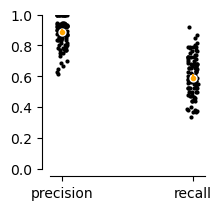

In [5]:
from matplotlib import pyplot as plt
from spikecurate.plotting import plot_precision_recall

fig, ax = plt.subplots(1, 1, figsize=(2, 2))
plot_precision_recall(ax, crossval_results["metric_data"])
plt.show()

## `model.train(dataset)`

Fit on the full dataset - this is the model you'd deploy.

In [6]:
model.train(dataset)
print("is_trained:", model.is_trained)

is_trained: True


/home/steeve/steeve/epfl/code/spikebias/envs/spikebias/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:1464: UserWarning: Elastic net fitting did not converge
  warnings.warn("Elastic net fitting did not converge")


## `model.predict(features)`

Classify units from their features alone. Below: the first 5 units in the
dataset, purely to show the output shape - `predict` doesn't use or need
their `quality_label`.

In [7]:
example_ids = list(dataset.index[:5])
predictions = model.predict(dataset.loc[example_ids, predictors])
predictions

,probability,predicted_label,predicted_quality
unit_id,,,
26,NaN,0,bad
29,NaN,0,bad
40,0.006578,0,bad
41,0.006993,0,bad
42,0.913419,1,good


### `predict()` raises before `train()`

In [8]:
untrained_model = FractionalLogisticClassifier(predictors)
try:
    untrained_model.predict(dataset.loc[example_ids, predictors])
except RuntimeError as e:
    print("RuntimeError:", e)

RuntimeError: call train() before predict()


## `model.score(dataset)`

Precision/recall of the trained model scored against the same data it was
trained on - expected to look better than `crossval_evaluate`'s held-out
numbers above; that gap is why cross-validation is the number to trust.

In [9]:
self_score = model.score(dataset)
print("self-score (trained on and scored against the same data):", self_score)
print("crossval median (held-out folds):", crossval_results["metric_stats"])

self-score (trained on and scored against the same data): {'precision': 0.9803921568627451, 'recall': 0.5952380952380952}
crossval median (held-out folds): {'precision_median': 0.8888888888888888, 'precision_std': 0.08995270167684924, 'precision_ci95': 0.017630729528662452, 'recall_median': 0.5909090909090909, 'recall_std': 0.12449134951248518, 'recall_ci95': 0.024400304504447096}
